In [1]:
# 1. Ekstraksi Mikro-Ekspresi (Spasial): Menggunakan Google MediaPipe untuk melacak titik 
#    wajah secara real-time dan menghitung metrik fisiologis:
#       a. Eye Aspect Ratio (EAR): Mengukur lebar bukaan mata.
#       b. Mouth Aspect Ratio (MAR): Mengukur aktivitas menguap.
#       c. Menambahkan fitur rotasi spasial 3D (Pitch, Yaw, Roll)
# 2. Analisis Derajat Kantuk (Temporal): Menggunakan jaringan Bidirectional LSTM (BiLSTM) 
#    karena kantuk bukanlah kejadian di satu detik waktu, melainkan transisi berangsur-
#    angsur (dari Alert ke Low Vigilant ke Drowsy).

# Persiapan install mediapipe
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 46.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [2]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ==========================================
# Ganti path ini ke lokasi dataset input Kaggle Anda
# ==========================================
# (Tidak ada proses download via internet/kode lagi!)
model_path = '/kaggle/input/datasets/adinur0611/ear-mar-features-uta-dataset-5000-frames/face_landmarker.task' 

# Konfigurasi opsi Face Landmarker
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1,                                
    min_face_detection_confidence=0.5,          
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,                
    output_face_blendshapes=True,               
    running_mode=vision.RunningMode.IMAGE       
)

# Inisialisasi MediaPipe Face Landmarker
face_mesh = vision.FaceLandmarker.create_from_options(options)

print("MediaPipe Face Landmarker siap digunakan (Offline mode dari Kaggle Input)!")

MediaPipe Face Landmarker siap digunakan (Offline mode dari Kaggle Input)!


W0000 00:00:1786361659.732194     133 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786361659.818246     139 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786361659.869045     140 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [3]:
# ==========================================
# STEP 2: Fungsi Ekstraksi 5 Fitur (EAR, MAR, Pitch, Yaw, Roll)
# ==========================================
def calculate_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def extract_facial_features(landmarks, frame_w, frame_h):
    # ------------------------------------------------
    # A. EKSTRAKSI EAR & MAR
    # ------------------------------------------------
    coords = [(int(pt.x * frame_w), int(pt.y * frame_h)) for pt in landmarks]
    
    left_eye = [coords[33], coords[160], coords[158], coords[133], coords[153], coords[144]]
    right_eye = [coords[362], coords[385], coords[387], coords[263], coords[373], coords[380]]
    
    def calc_ear(eye):
        v1 = calculate_distance(eye[1], eye[5])
        v2 = calculate_distance(eye[2], eye[4])
        h = calculate_distance(eye[0], eye[3])
        return (v1 + v2) / (2.0 * h) if h != 0 else 0
    
    ear = (calc_ear(left_eye) + calc_ear(right_eye)) / 2.0
    
    mouth = [coords[78], coords[81], coords[13], coords[311], coords[308], coords[402], coords[14], coords[178]]
    v1_m = calculate_distance(mouth[1], mouth[7])
    v2_m = calculate_distance(mouth[2], mouth[6])
    v3_m = calculate_distance(mouth[3], mouth[5])
    h_m = calculate_distance(mouth[0], mouth[4])
    
    mar = (v1_m + v2_m + v3_m) / (2.0 * h_m) if h_m != 0 else 0

    # ------------------------------------------------
    # B. EKSTRAKSI HEAD POSE (PITCH, YAW, ROLL)
    # ------------------------------------------------
    # Koordinat 3D Wajah Generik (Titik Acuan Dunia)
    face_3d = np.array([
        (0.0, 0.0, 0.0),            # Hidung (Nose tip) - Index 1
        (0.0, -330.0, -65.0),       # Dagu (Chin) - Index 152
        (-225.0, 170.0, -135.0),    # Ujung Mata Kiri - Index 33
        (225.0, 170.0, -135.0),     # Ujung Mata Kanan - Index 263
        (-150.0, -150.0, -125.0),   # Ujung Mulut Kiri - Index 61
        (150.0, -150.0, -125.0)     # Ujung Mulut Kanan - Index 291
    ], dtype=np.float64)

    # Ambil koordinat 2D pixel dari 6 titik referensi di atas
    face_2d = []
    for idx in [1, 152, 33, 263, 61, 291]:
        x, y = int(landmarks[idx].x * frame_w), int(landmarks[idx].y * frame_h)
        face_2d.append([x, y])
    face_2d = np.array(face_2d, dtype=np.float64)

    # Setup matriks kamera tiruan (Asumsi sentral / tidak terdistorsi)
    focal_length = 1 * frame_w
    cam_matrix = np.array([
        [focal_length, 0, frame_h / 2],
        [0, focal_length, frame_w / 2],
        [0, 0, 1]
    ], dtype=np.float64)
    dist_matrix = np.zeros((4, 1), dtype=np.float64)

    # Selesaikan PnP untuk mendapatkan vektor rotasi
    success, rot_vec, trans_vec = cv2.solvePnP(face_3d, face_2d, cam_matrix, dist_matrix)

    # Konversi vektor rotasi menjadi Matrix Rotasi, lalu ke Euler Angles (derajat)
    rmat, _ = cv2.Rodrigues(rot_vec)
    angles, _, _, _, _, _ = cv2.RQDecomp3x3(rmat)
    
    pitch = angles[0] # Gerakan Mengangguk (Menunduk/Mendongak)
    yaw = angles[1]   # Gerakan Menoleh (Kiri/Kanan)
    roll = angles[2]  # Gerakan Miring (Kepala jatuh ke pundak)

    return ear, mar, pitch, yaw, roll

In [4]:
# Step 3: Pipeline Pemrosesan Video Menjadi Dataset Sekuensial
# mengekstraksi frame per detik (FPS) tertentu untuk menekan ukuran RAM.

import os
import cv2
import glob
import numpy as np
import mediapipe as mp

# ==========================================
# 1. KONFIGURASI PARAMETER
# ==========================================
# Ganti ini jika path dataset Kaggle Anda berbeda
DATASET_PATH = "/kaggle/input/datasets/rishab260/uta-reallife-drowsiness-dataset" 

SEQ_LENGTH = 30         # Berapa frame untuk mendeteksi 1 status kantuk? (30 frame = ~1 sequence)
FRAME_SKIP = 5          # Ambil 1 frame setiap 5 frame (Mempercepat processing 5x lipat)
MAX_FRAMES_PER_VIDEO = 5000 # Batas maksimum frame per video agar tidak OOM (600 = representatif)

# ==========================================
# 2. FUNGSI PEMROSESAN VIDEO INDIVIDU
# ==========================================
def extract_features_from_video(video_path):
    cap = cv2.VideoCapture(video_path)
    features = []
    frame_count = 0
    extracted_count = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        
        # Berhenti jika video habis atau sudah mencapai batas representatif
        if not ret or extracted_count >= MAX_FRAMES_PER_VIDEO:
            break
            
        # Trik Optimasi: Jangan proses setiap frame!
        if frame_count % FRAME_SKIP == 0:
            # Ubah ukuran frame menjadi lebih kecil (misal lebar 640, tinggi proporsional)
            frame = cv2.resize(frame, (640, 480))
            
            # Konversi BGR ke RGB
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # --- [PERUBAHAN UNTUK TASKS API] ---
            # 1. Bungkus frame menjadi objek mp.Image
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            
            # 2. Proses menggunakan face_mesh (Tasks API)
            results = face_mesh.detect(mp_image) 
            
            # 3. Cek array 'face_landmarks' (bukan multi_face_landmarks)
            if results.face_landmarks:
                # Ambil wajah pertama
                # Catatan: Struktur Tasks API mengembalikan list langsung.
                landmarks = results.face_landmarks[0]
                
                # Panggil fungsi ekstraksi 5 Fitur (EAR, MAR, Pitch, Yaw, Roll)
                ear, mar, pitch, yaw, roll = extract_facial_features(landmarks, frame.shape[1], frame.shape[0])
                
                # Masukkan kelima fitur ke dalam list
                features.append([ear, mar, pitch, yaw, roll])
            else:
                # Padding jika wajah tidak terdeteksi (tambahkan 3 angka nol untuk sudut)
                features.append([0.3, 0.0, 0.0, 0.0, 0.0])
            # -----------------------------------
            
            extracted_count += 1
            
        frame_count += 1
        
    cap.release()
    return features

# ==========================================
# 3. PIPELINE CRAWLING & EKSTRAKSI MASSAL
# ==========================================
X_all = []
y_all = []

# Cari semua file video dalam seluruh sub-folder Kaggle
video_files = glob.glob(os.path.join(DATASET_PATH, '**', '*.*'), recursive=True)
video_files = [f for f in video_files if f.lower().endswith(('.mp4', '.mov', '.avi'))]

print(f"Total video ditemukan: {len(video_files)}")
print("Memulai ekstraksi fitur wajah... (Ini akan memakan waktu, silakan tunggu)\n")

for idx, video_path in enumerate(video_files):
    filename = os.path.basename(video_path).lower()
    
    # Identifikasi Label dari nama file standar UTA-RLDD
    if filename.startswith('0.'):
        label = 0   # Alert
    elif filename.startswith('5.'):
        label = 1   # Low Vigilant
    elif filename.startswith('10.'):
        label = 2   # Drowsy
    else:
        continue    # Lewati file asing (jika ada)
        
    print(f"[{idx+1}/{len(video_files)}] Ekstraksi: {filename} (Label: {label})")
    
    # Tarik fitur EAR & MAR (Bentuk: [Jumlah_Frame_Terekstrak, 2])
    video_features = extract_features_from_video(video_path)
    
    # ==========================================
    # 4. PEMBENTUKAN SLIDING WINDOW (TEMPORAL)
    # ==========================================
    # Pecah deretan panjang menjadi sequence kecil untuk LSTM
    if len(video_features) >= SEQ_LENGTH:
        for i in range(len(video_features) - SEQ_LENGTH):
            sequence = video_features[i : i + SEQ_LENGTH]
            X_all.append(sequence)
            y_all.append(label)

# ==========================================
# 5. PENYIMPANAN DATASET AKHIR (CHECKPOINTING)
# ==========================================
X_data = np.array(X_all)
y_data = np.array(y_all)

print("\n" + "="*40)
print("EKSTRAKSI SELESAI!")
print(f"Bentuk Akhir X_data : {X_data.shape}")
print(f"Bentuk Akhir y_data : {y_data.shape}")
print("="*40)

# Simpan sebagai file Numpy (.npy) di output Kaggle
np.save('/kaggle/working/X_features_rldd.npy', X_data)
np.save('/kaggle/working/y_labels_rldd.npy', y_data)
print("\nSukses! Data disimpan sebagai 'X_features_rldd.npy' dan 'y_labels_rldd.npy'.")
print("Anda bisa langsung me-load file ini untuk Step 4 (Pelatihan Model) kapan saja.")

Total video ditemukan: 143
Memulai ekstraksi fitur wajah... (Ini akan memakan waktu, silakan tunggu)

[1/143] Ekstraksi: 5.mp4 (Label: 1)
[2/143] Ekstraksi: 10.mp4 (Label: 2)
[3/143] Ekstraksi: 0.mp4 (Label: 0)
[4/143] Ekstraksi: 5.mp4 (Label: 1)
[5/143] Ekstraksi: 10.mp4 (Label: 2)
[6/143] Ekstraksi: 0.mp4 (Label: 0)
[7/143] Ekstraksi: 5.mp4 (Label: 1)
[8/143] Ekstraksi: 10.mp4 (Label: 2)
[9/143] Ekstraksi: 0.mp4 (Label: 0)
[10/143] Ekstraksi: 5.mp4 (Label: 1)
[11/143] Ekstraksi: 10.mov (Label: 2)
[12/143] Ekstraksi: 0.mov (Label: 0)
[13/143] Ekstraksi: 10.mov (Label: 2)
[14/143] Ekstraksi: 10.mov (Label: 2)
[15/143] Ekstraksi: 0.mov (Label: 0)
[16/143] Ekstraksi: 5.mov (Label: 1)
[17/143] Ekstraksi: 10.mov (Label: 2)
[18/143] Ekstraksi: 0.mov (Label: 0)
[19/143] Ekstraksi: 5.mov (Label: 1)
[20/143] Ekstraksi: 10.mov (Label: 2)
[21/143] Ekstraksi: 0.mov (Label: 0)
[22/143] Ekstraksi: 5.mov (Label: 1)
[23/143] Ekstraksi: 5.mp4 (Label: 1)
[24/143] Ekstraksi: 10.mp4 (Label: 2)
[25/143] E

In [5]:
import os
from IPython.display import display, FileLink

# 1. Kita cek dulu apakah filenya benar-benar berhasil terbuat
print("Daftar file di /kaggle/working/:")
print(os.listdir('/kaggle/working/'))
print("-" * 30)

# 2. Buat link download untuk X_features
if os.path.exists('X_features_rldd.npy'):
    print("Klik link di bawah untuk mendownload X_features:")
    display(FileLink('X_features_rldd.npy'))
else:
    print("❌ File X_features_rldd.npy tidak ditemukan. Ekstraksi mungkin gagal di tengah jalan.")

# 3. Buat link download untuk y_labels
if os.path.exists('y_labels_rldd.npy'):
    print("\nKlik link di bawah untuk mendownload y_labels:")
    display(FileLink('y_labels_rldd.npy'))
else:
    print("❌ File y_labels_rldd.npy tidak ditemukan.")

Daftar file di /kaggle/working/:
['.virtual_documents', 'y_labels_rldd.npy', 'X_features_rldd.npy']
------------------------------
Klik link di bawah untuk mendownload X_features:


/kaggle/working/X_features_rldd.npy


Klik link di bawah untuk mendownload y_labels:


/kaggle/working/y_labels_rldd.npy

=== Memuat Fitur dan Label ===
Sukses memuat data!
Bentuk X (Sample, Timesteps, Features): (472279, 30, 5)
Bentuk y (Sample,): (472279,)

=== Distribusi Data ===
Data Latih (Train)      : (377823, 30, 5) | Label: (377823, 3)
Data Validasi (Val)     : (47228, 30, 5) | Label: (47228, 3)
Data Uji (Test)         : (47228, 30, 5) | Label: (47228, 3)


I0000 00:00:1786393861.503282      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786393861.506201      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,419 (329.76 KB)

 Trainable params: 83,907 (327.76 KB)

 Non-trainable params: 512 (2.00 KB)


=== Memulai Pelatihan Model ===
Epoch 1/50
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4755 - loss: 1.0829
Epoch 1: val_loss improved from None to 0.77917, saving model to EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_bilstm.keras

Epoch 1: finished saving model to EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_bilstm.keras
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 97s 15ms/step - accuracy: 0.5417 - loss: 0.9790 - val_accuracy: 0.6615 - val_loss: 0.7792 - learning_rate: 0.0010
Epoch 2/50
5901/5904 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6482 - loss: 0.8108
Epoch 2: val_loss improved from 0.77917 to 0.67674, saving model to EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_bilstm.keras

Epoch 2: finished saving model to EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_bilstm.keras
5904/5904 ━━━━━━━━━━━━━━━━━━━━ 88s 15ms/step - accuracy: 0.6659 - loss: 0.7828 - val_accuracy: 0.7220 - val_loss: 0.6767 - learning_rate: 0.0010
Epoch 3/50
5904/5904 ━━━━━━━━━━━━━━━

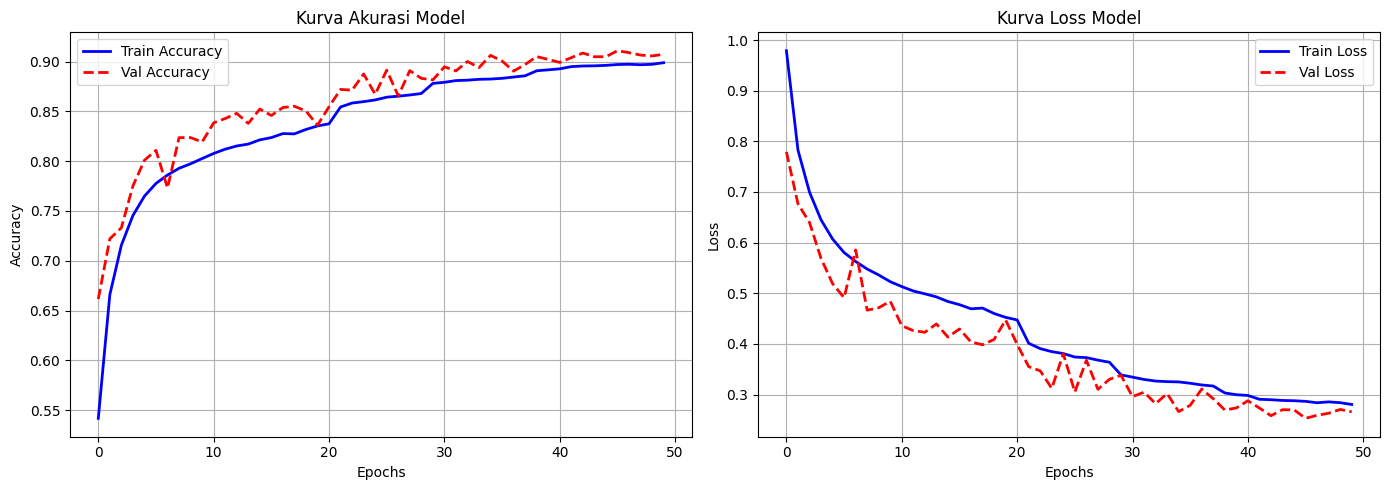

1476/1476 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step

=== Classification Report ===
                  precision    recall  f1-score   support

       Alert (0)       0.89      0.93      0.91     15928
Low Vigilant (5)       0.91      0.90      0.90     15470
     Drowsy (10)       0.93      0.91      0.92     15830

        accuracy                           0.91     47228
       macro avg       0.91      0.91      0.91     47228
    weighted avg       0.91      0.91      0.91     47228



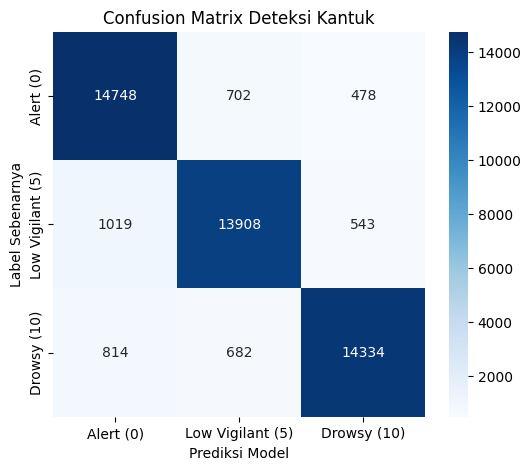

In [1]:
# Step 4 (Pembuatan & Pelatihan Model BiLSTM)
# Terdiri atas: 
#   1. Stratified Splitting (secara aman pada label 1D), 
#   2. Regularisasi L2 & Batch Normalization, 
#   3. Advanced Callbacks untuk mencegah overfitting.

import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# ==========================================
# 1. LOAD DATASET HASIL EKSTRAKSI STEP 3
# ==========================================
print("=== Memuat Fitur dan Label ===")
try:
    X = np.load('/kaggle/input/datasets/adinur0611/ear-mar-features-uta-dataset-5000-frames/X_features_rldd_head_pose.npy')
    y = np.load('/kaggle/input/datasets/adinur0611/ear-mar-features-uta-dataset-5000-frames/y_labels_rldd_head_pose.npy')
    print(f"Sukses memuat data!")
    print(f"Bentuk X (Sample, Timesteps, Features): {X.shape}")
    print(f"Bentuk y (Sample,): {y.shape}")
except FileNotFoundError:
    print("❌ Error: File .npy tidak ditemukan di /kaggle/input/.")
    print("Pastikan Step 3 dijalankan dengan sukses sebelum menjalankan cell ini.")
    sys.exit(1)

# ==========================================
# 2. PREPROCESSING & STRATIFIED SPLITTING
# ==========================================
# PERBAIKAN: Bagi data menggunakan label mentah 1D (y) agar 'stratify' bekerja sempurna
# Pembagian data: 80% Train, 10% Validation, 10% Test
X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp_raw, test_size=0.5, random_state=42, stratify=y_temp_raw
)

# Lakukan One-Hot Encoding SETELAH data terbagi (format probabilitas matriks)
y_train = to_categorical(y_train_raw, num_classes=3)
y_val = to_categorical(y_val_raw, num_classes=3)
y_test = to_categorical(y_test_raw, num_classes=3)

print("\n=== Distribusi Data ===")
print(f"Data Latih (Train)      : {X_train.shape} | Label: {y_train.shape}")
print(f"Data Validasi (Val)     : {X_val.shape} | Label: {y_val.shape}")
print(f"Data Uji (Test)         : {X_test.shape} | Label: {y_test.shape}")

# ==========================================
# 3. MEMBANGUN ARSITEKTUR BILSTM FUSION
# ==========================================
def build_bilstm_model(input_shape):
    model = Sequential([
        # PERBAIKAN KERAS 3: Gunakan Input layer eksplisit
        Input(shape=input_shape),
        
        # Layer 1: Bidirectional LSTM Pertama
        Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))),
        BatchNormalization(),
        Dropout(0.4),
        
        # Layer 2: Bidirectional LSTM Kedua
        Bidirectional(LSTM(32, return_sequences=False)),
        BatchNormalization(),
        Dropout(0.4),
        
        # Layer 3: Dense Fusion Layer 1
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Layer 4: Dense Fusion Layer 2
        Dense(32, activation='relu'),
        
        # Layer Output: Softmax Klasifikasi Multi-kelas (3 Derajat Kantuk)
        Dense(3, activation='softmax')
    ])
    
    return model

input_shape = (X_train.shape[1], X_train.shape[2]) # (30, 2)
model = build_bilstm_model(input_shape)

# Kompilasi Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 4. SETTING CALLBACKS
# ==========================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_bilstm.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# ==========================================
# 5. PROSES TRAINING MODEL
# ==========================================
print("\n=== Memulai Pelatihan Model ===")
EPOCHS = 50
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

# ==========================================
# 6. EVALUASI DAN VISUALISASI KINERJA
# ==========================================
print("\n=== Evaluasi Akhir Model ===")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Akurasi Akhir pada Data Uji: {test_acc * 100:.2f}%")
print(f"Loss Akhir pada Data Uji   : {test_loss:.4f}")

# Plotting Loss dan Accuracy
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='b', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='r', linestyle='--', linewidth=2)
plt.title('Kurva Akurasi Model', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='b', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='r', linestyle='--', linewidth=2)
plt.title('Kurva Loss Model', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 7. MATRIKS EVALUASI LANJUTAN
# ==========================================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

target_names = ['Alert (0)', 'Low Vigilant (5)', 'Drowsy (10)']

print("\n=== Classification Report ===")
print(classification_report(y_test_raw, y_pred_classes, target_names=target_names))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_raw, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix Deteksi Kantuk')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.show()

In [2]:
import os
from IPython.display import display, FileLink

print("=== DAFTAR MODEL TERBAIK ===")

# 1. Buat link download untuk Model Utama (EAR & MAR)
if os.path.exists('EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_bilstm.keras'):
    print("\n✅ Klik link di bawah untuk mendownload Model BiLSTM Utama (EAR & MAR & Head Pose):")
    display(FileLink('EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_bilstm.keras'))
else:
    print("\n❌ File 'EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_bilstm.keras' tidak ditemukan.")

=== DAFTAR MODEL TERBAIK ===

✅ Klik link di bawah untuk mendownload Model BiLSTM Utama (EAR & MAR & Head Pose):


/kaggle/working/EAR_MAR_HeadPose_5000_frames_30_seq_best_drowsiness_bilstm.keras